----
#### Etape 1 : Importation des bibliotheques

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models # type: ignore

----
#### Etape 2 :  EDA


In [ ]:
# Chargement des données
data = pd.read_csv('5g_ddos.csv')

In [ ]:
data.head()

,index,Src IP,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Fwd Packet Length Std,ACK Flag Count,Fwd Seg Size Min,label,Slice
0,0,-0.076421,-1.307166,-0.281574,-0.250848,0.743614,-0.004038,-0.539543,-0.003012,0.019988,1,0.0
1,1,-0.076070,-1.272295,-0.281574,-0.250848,-0.798923,-0.004038,1.779607,-0.002760,0.019988,1,1.0
2,2,-0.076070,0.917363,-0.281574,-0.250848,-0.798931,-0.005045,-0.539543,-0.002760,0.019988,1,1.0
3,3,-0.076421,1.002194,-0.281574,-0.250848,-0.798931,-0.005045,-0.539543,-0.002760,0.019988,1,0.0
4,4,-0.076421,-1.493784,-0.281574,-0.250848,-0.798920,-0.004038,1.779607,-0.002760,0.019988,1,0.0


In [ ]:
data.describe()

,index,Src IP,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Fwd Packet Length Std,ACK Flag Count,Fwd Seg Size Min,label,Slice
count,6.171315e+06,6.171315e+06,6.171315e+06,6.171315e+06,6.171315e+06,6.171314e+06,6.171315e+06,6.171315e+06,6.171315e+06,6.171315e+06,6.171315e+06,6.171315e+06
mean,3.085657e+06,9.807776e-17,-1.646910e-17,-1.481114e-17,-1.072150e-16,-7.368728e-19,5.007050e-17,3.104214e-16,6.215521e-17,-1.802575e-16,8.882726e-01,4.795521e-01
std,1.781505e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.150308e-01,4.995817e-01
min,0.000000e+00,-7.254831e-01,-1.587850e+00,-2.885922e-01,-2.559348e+00,-7.989311e-01,-5.045237e-03,-5.395427e-01,-3.012201e-03,-4.935519e+00,0.000000e+00,0.000000e+00
25%,1.542828e+06,-7.642110e-02,-9.020866e-01,-2.815739e-01,-2.508476e-01,-7.989304e-01,-5.045237e-03,-5.395427e-01,-3.012201e-03,1.998756e-02,1.000000e+00,0.000000e+00
50%,3.085657e+06,-7.642109e-02,7.657292e-02,-2.815739e-01,-2.508476e-01,-7.986901e-01,-4.037938e-03,-5.395427e-01,-2.759889e-03,1.998756e-02,1.000000e+00,0.000000e+00
75%,4.628486e+06,-7.606967e-02,8.646782e-01,-2.815739e-01,-2.508476e-01,7.750473e-01,-4.037938e-03,-5.395427e-01,-2.759889e-03,1.998756e-02,1.000000e+00,1.000000e+00
max,6.171314e+06,1.895666e+01,1.719346e+00,5.460562e+00,3.981403e+00,2.741539e+01,1.434718e+03,8.472010e+00,1.434537e+03,9.931001e+00,1.000000e+00,1.000000e+00


In [ ]:
data["Slice"].value_counts()

Slice
0.0    3211848
1.0    2959467
Name: count, dtype: int64

In [ ]:
data.isna().sum()

index                    0
Src IP                   0
Src Port                 0
Dst Port                 0
Protocol                 0
Flow Duration            1
Total Fwd Packet         0
Fwd Packet Length Std    0
ACK Flag Count           0
Fwd Seg Size Min         0
label                    0
Slice                    0
dtype: int64

In [ ]:
sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True)

In [ ]:
# Index ne sert a rien donc le supprimer
data = data.drop('index', axis=1)

# Seul Flow duration a une ligne vide, donc on supprime la ligne
data_clean = data.dropna()

# On retire 'label' et 'Fwd Seg Size Min' et 'Slice' de X, car 'label' est la target et les deux autres sont des caractéristiques non pertinentes pour notre modélisation.
cols_to_drop = ['label', 'Fwd Seg Size Min', 'Slice']
X = data_clean.drop(cols_to_drop, axis=1)  #features
Y = data_clean['label'] #target
FEATURE_COLS = [c for c in X.columns]
print('Shape de X:', X.shape)
print('Shape de Y:', Y.shape)

print('Features :', FEATURE_COLS)
print('\nClasses de la cible :')
print(Y.value_counts())

Shape de X: (6171314, 8)
Shape de Y: (6171314,)
Features : ['Src IP', 'Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Fwd Packet Length Std', 'ACK Flag Count']

Classes de la cible :
label
1    5481810
0     689504
Name: count, dtype: int64


----
#### Etape 3 : Modèle baseline

C'est ce modèle qu'on va reproduire, puis améliorer avec l'apprentissage fédéré.

Hyperparamètres­ 

In [ ]:
# Hyperparamètres 
EPOCHS = 2
BATCH_SIZE = 256
#SAMPLE_BASELINE = 300_000  
N_FEATURES = 8      

In [ ]:
# Modele CNN
def create_baseline():
    model = models.Sequential()
    #ReLU élimine les activations négatives pour introduire de la non-linéarité.
    # Features reshapées en sequence (8,1)
    model.add(layers.Input(shape = (N_FEATURES, 1)))
    # Extraire les patterns locaux entre features par exple debit eleve + duree courte + beaucoup de paquet = DoS (6,32)
    model.add(layers.Conv1D(32, kernel_size = 3, activation = 'relu'))
    # Reduit la dimension en faisant la moyenne sur une fenetre de 2 (3,32)
    model.add(layers.AveragePooling1D(pool_size = 2))
    #Convertit les tenseurs 2D issus du pooling en un vecteur 1D pour alimenter les couches denses. [96 Valeurs]
    model.add(layers.Flatten())
    #Les 96 valeurs passent dans une couche entièrement connectée de 16 neurones. 
    # Chaque neurone reçoit les 96 valeurs, les combine avec ses propres poids, 
    # et applique la fonction sigmoid qui écrase le résultat entre 0 et 1 ou relu
    model.add(layers.Dense(16, activation = 'relu'))
    #La couche finale réduit les 16 valeurs à une seule valeur entre 0 et 1 :
    model.add(layers.Dense(1, activation = 'sigmoid'))
    model.compile(
        loss = 'binary_crossentropy',
        optimizer = 'adam',
        metrics = ['accuracy']
    )
    return model

# Séparation des données. Partie entrainement et partie validation
X_train_b, X_test_b, Y_train_b, Y_test_b = train_test_split(X, Y, test_size = 0.2, random_state = 42)
# Normalisation
scaler_b = StandardScaler()
X_train_b = scaler_b.fit_transform(X_train_b)
X_test_b = scaler_b.transform(X_test_b)

X_train_b = X_train_b.reshape(-1, N_FEATURES, 1)
X_test_b = X_test_b.reshape(-1, N_FEATURES, 1) 

print('Shape X_train baseline:', X_train_b.shape)
print('Shape X_test baseline:', X_test_b.shape)

Shape X_train baseline: (4937051, 8, 1)
Shape X_test baseline: (1234263, 8, 1)


----
#### Etape 4 : Entraînement baseline

In [ ]:
print('Entraînement du modèle ...')

model_baseline = create_baseline()
hist_baseline = model_baseline.fit(
    #X_train_b[:SAMPLE_BASELINE], Y_train_b.iloc[:SAMPLE_BASELINE],
    X_train_b, Y_train_b,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_split = 0.1,
    verbose = 1,
    class_weight = {0: 8, 1: 1}
)
print('\nBaseline prête')

Entraînement du modèle
Epoch 1/2
17357/17357 ━━━━━━━━━━━━━━━━━━━━ 77s 4ms/step - accuracy: 0.9707 - loss: 0.1293 - precision: 0.9988 - recall: 0.9682 - val_accuracy: 0.9996 - val_loss: 0.0055 - val_precision: 0.9995 - val_recall: 1.0000
Epoch 2/2
17357/17357 ━━━━━━━━━━━━━━━━━━━━ 75s 4ms/step - accuracy: 0.9998 - loss: 0.0133 - precision: 0.9998 - recall: 0.9999 - val_accuracy: 0.9999 - val_loss: 0.0012 - val_precision: 0.9999 - val_recall: 1.0000

Baseline prete


----
#### Etape 5 : Matrice de confusion baseline

 BASELINE 
Precision (Accuracy) :  0.9999
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    138311
        DDoS       1.00      1.00      1.00   1095952

    accuracy                           1.00   1234263
   macro avg       1.00      1.00      1.00   1234263
weighted avg       1.00      1.00      1.00   1234263



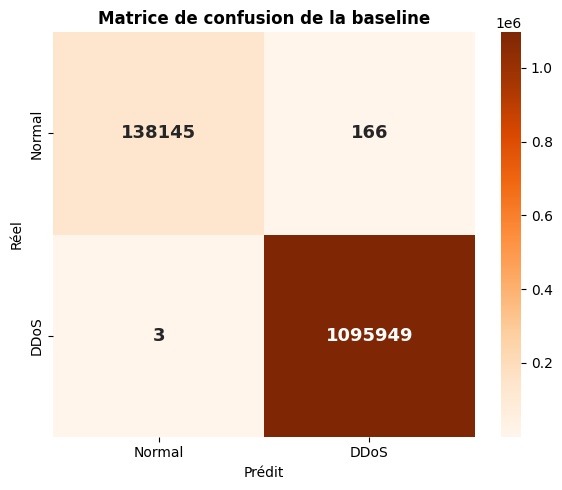

Sauvegardé : confusion_baseline.png


In [ ]:
# Évaluation baseline
loss_b, acc_b = model_baseline.evaluate(X_test_b, Y_test_b, verbose = 0)
Y_pred_b = (model_baseline.predict(X_test_b, verbose = 0) > 0.5).astype(int).flatten()

print(' BASELINE ')
print(f'Precision (Accuracy) : {acc_b : .4f}')
print(classification_report(Y_test_b, Y_pred_b, target_names = ['Normal','DDoS']))

# Matrice de confusion baseline
fig, ax = plt.subplots(figsize = (6,5))
cmt_b = confusion_matrix(Y_test_b, Y_pred_b)
sns.heatmap(cmt_b, annot = True, fmt = 'd', cmap='Oranges', ax = ax,
            xticklabels = ['Normal','DDoS'], yticklabels = ['Normal','DDoS'],
            annot_kws = {'size' : 13,'weight' : 'bold'})
ax.set_title('Matrice de confusion de la baseline', fontweight = 'bold')
ax.set_ylabel('Réel') ; ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig('confusion_baseline.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print('Sauvegardé : confusion_baseline.png')

In [ ]:
print("Lancement de la Validation Croisée (3-Fold)...")

X_fold_sample = X.values.reshape(-1, N_FEATURES, 1)
Y_fold_sample = Y

kf = KFold(n_splits = 3, shuffle = True, random_state = 42)
cv_accuracies = []

for i, (train_idx, val_idx) in enumerate(kf.split(X_fold_sample)):
    # Création d'un nouveau modèle pour chaque fold
    model_fold = create_baseline()
    
    # Entraînement
    model_fold.fit(X_fold_sample[train_idx], Y_fold_sample.iloc[train_idx], 
                   epochs=EPOCHS, batch_size=BATCH_SIZE, verbose = 0)
    
    # Évaluation
    _, acc = model_fold.evaluate(X_fold_sample[val_idx], Y_fold_sample.iloc[val_idx], verbose = 0)
    cv_accuracies.append(acc)
    print(f"Précision pour le Fold {i+1} : {acc:.4f}")

print(f"\nPrécision Moyenne CV : {np.mean(cv_accuracies):.4f} (+/- {np.std(cv_accuracies):.4f})")

Lancement de la Validation Croisée (3-Fold)...
Précision pour le Fold 1 : 0.9999
Précision pour le Fold 2 : 0.9996
Précision pour le Fold 3 : 0.9999

Précision Moyenne CV : 0.9998 (+/- 0.0001)
